In [ ]:
# data preprocessing steps after understanding the data see part a for understanding data before preprocessing

# 1. data transformation steps
# data integration merging after merging
# duplicates drop
# data cleaning [missing values]
# Inconsistencies/Anomalies [inconsistent names, inconsistent formats, contradictory data like son age > father age]
# outliers
# other data transformation after above done[categorical data encode and numerical data standardize or normalize]
# above are all data transformation steps

# other steps include ---- 
# 2. feature construction -- create new column based on domain knowledge
# 3. feature selection --- backward selection forward elimination
# 4. feature extraction --- PCA LDA t-SNE 

In [ ]:
# data transformation includes

# missing value imputation
# handling categorical features[encoding]
# outlier detection
# feature scaling[age and salary bring in same scale to compare]

# Part 1

In [ ]:
# feature scaling   --- independent features bring in a fixed range.
# for machine to understand features data we do following things 

# categorical data -- encoded 

# numerical data --- 1. standardize[use when normal distribution --- it only scales/helps in reducing effect of outliers] -- handle outlers before scaling    
# 2. or normalize[use when not normal distr. --- it scales + normalizes distribution] 

# standardization -- only scales -- [mean 0 SD 1] --- also called z score formula (x-xbar)/sigma
# 1.min max scalar (0 to 1)  -- data must be positive
# 2.standard scaler 
# 3.max absolute scaler(-1 to 1)
# if algo. to be used can handle -ve values then use standard scalar or max absolute scalar 
# if not then use min max scalar

# Normalization -- use when not normal distribution -- scales plus normalizes
# transformers used to normalize  -- they direct convert to ND plus scales -- used to reduce skewness
# 1. Box Cox -- data must be positive -- only converts to ND -- works on skewed to Normal distribution
# 2. yeo johnson -- skewed to normal convert
# 3. quantile transformer  -- skewed or uniform or bimodel to normal convert
# 4. other normalization techniques for text data --- L1 normalization  and L2 normalization

# main difference between Normalization and standardization. standardization changes all values together while normalization individual values changes to convert to normal dist
# standardization used to change the range of data without altering the shape of its distribution
# normalization adjusts the scale of the data plus changes the shape of its distribution like skewed data to ND.
# normalization techniques ---- log transform -- square root transform -- box cox transform   ---- all used to reduce skewness
# log transform also used for outliers plus scaling

# sometimes normalization word is used for some standardization techniques just remember which techniques are used to change scale only
# and which used to change scale plus distribution to ND

In [ ]:
# StandardScaler   mean 0 and scale[-3,3] but bcz of outliers scale can be big to fix outliers then use it.

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Data/Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df=df.iloc[:,2:]  #last 3 columns only -- 1st : means all rows plus 2nd 2: means from 3rd column till end column return -- 1st row#,2nd column#
df.sample(5)

,Age,EstimatedSalary,Purchased
399,49,36000,1
360,43,129000,1
112,38,61000,0
209,46,22000,0
99,28,37000,0


In [5]:
# Train test split
# recommended to first split then scale

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),   #this means x independent variables except purchased
                                                    df['Purchased'],                #this means y output variable purchased
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape


((280, 2), (120, 2))

In [6]:
# StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)     #fit only on train data bcz learning only from train data then tranform on both train test the learned thing here mean.Age
                        # fit only on train data means calculate the mean for scaler onces through train data only then use the same calculated mean to transform both train test. onces the formula calculated fit no need to seperately calculate for train also
# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
scaler.mean_        #fit calculated this formula on train data and now this will be used on both train test transform no sep formula mean for test. use same mean value for both test train transform.bcz you learn only from train data not test data.

array([3.78642857e+01, 6.98071429e+04])

In [10]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [11]:
X_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [12]:
# converting from numpy to dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [13]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [ ]:
np.round(X_train_scaled.describe(), 1)         #you can see mean become 0 and SD 1 bcz of standardization applied now both columns are comparable age and salary

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


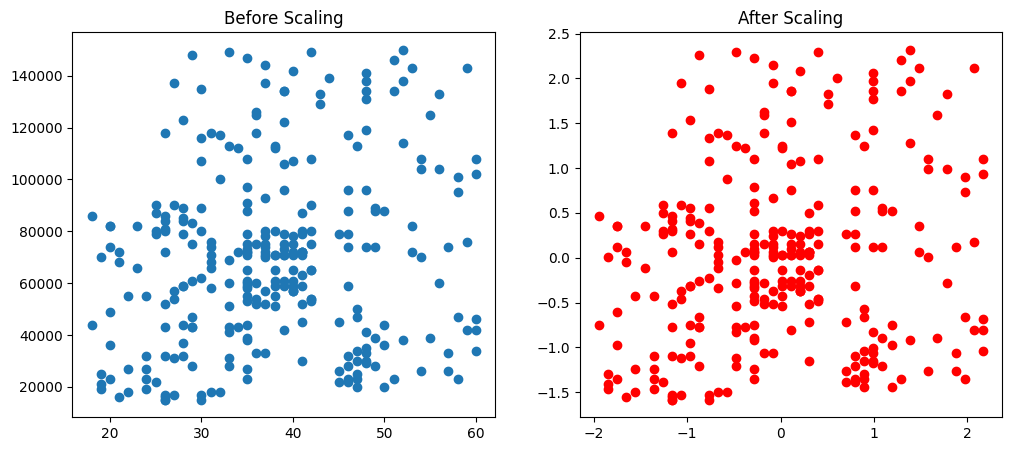

In [15]:
# Effect of Scaling   # when scatter plot no difference shape data just scale changed.so scaling doesnt effect the info data only changes scale
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

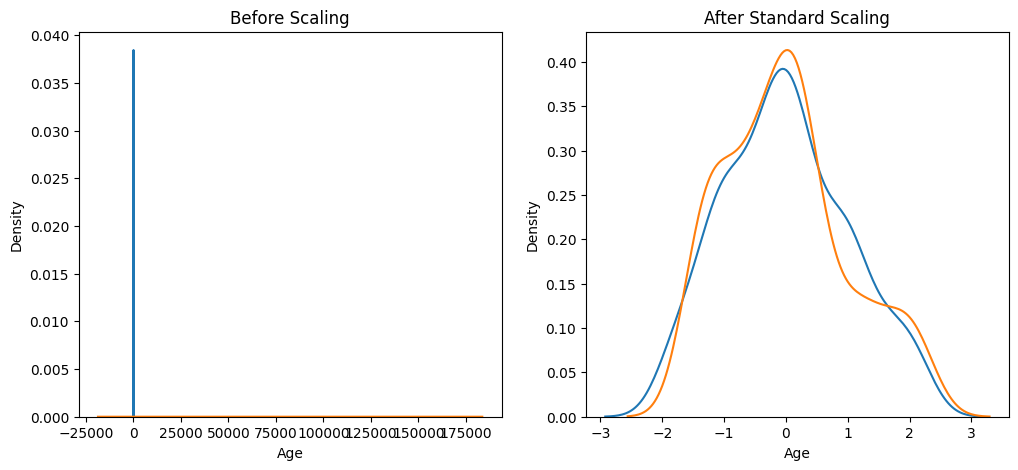

In [ ]:
# kde plot -- for before case kde was not able to compare age and salary bcz of huge scale difference uncomparable before but in after case properly ploted distrubution curves for age and salary
# kde shows the data are normal distribution that means standardization will apply not normalization 
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()



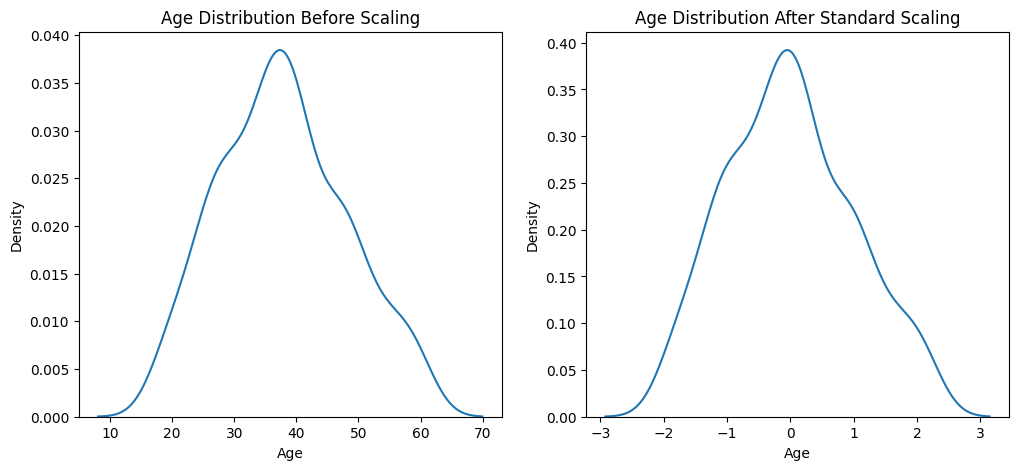

In [18]:
# you can plot age and salary sep in before case -- than compare before after age column only you will see kde distribution same only scale chnaged
# Comparison of Distributions
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
plt.show()

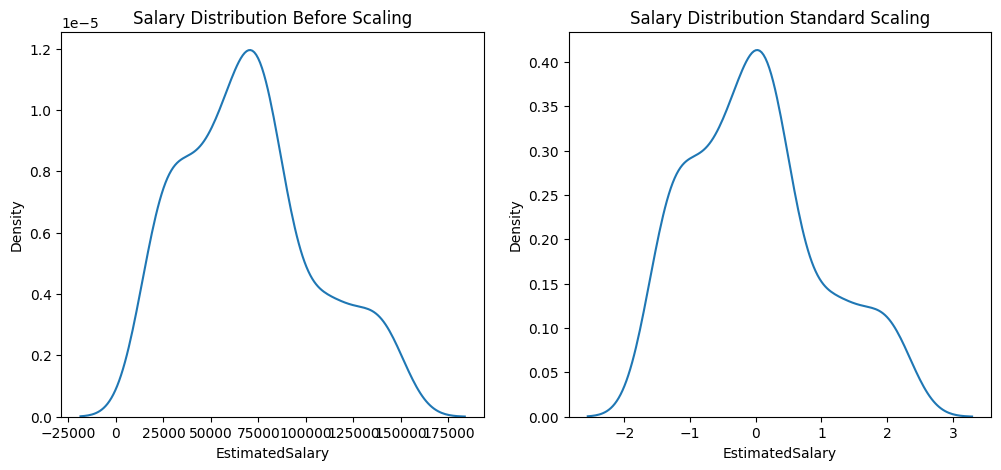

In [19]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('Salary Distribution Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

In [20]:
# Why scaling is important?
# most algo work better on scaled data like logistic regression, k means, KNN, PCA, Gradient descent etc   
# but algo like decision tree, random forest, gradient boost, XG boost scaling not required.

from sklearn.linear_model import LogisticRegression

In [22]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [23]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [24]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [25]:
from sklearn.metrics import accuracy_score

In [26]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


In [27]:
from sklearn.tree import DecisionTreeClassifier

In [28]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [29]:
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [30]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [31]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.875


In [32]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [ ]:
# Effect of Outlier   --- lets include some outlers in the data and study the results.
# standardization only scales plus helps in reducing effect of outliers. 
# recommanded to handle outlers before scaling
df = pd.concat([
    df,
    pd.DataFrame({
        'Age': [5, 90, 95],
        'EstimatedSalary': [1000, 250000, 350000],
        'Purchased': [0, 1, 1]
    })
], ignore_index=True)

In [35]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


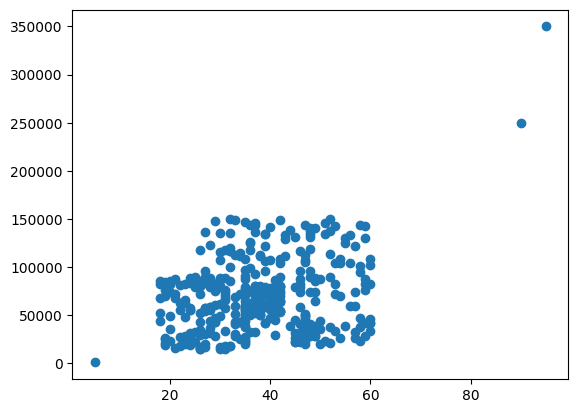

In [36]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((282, 2), (121, 2))

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

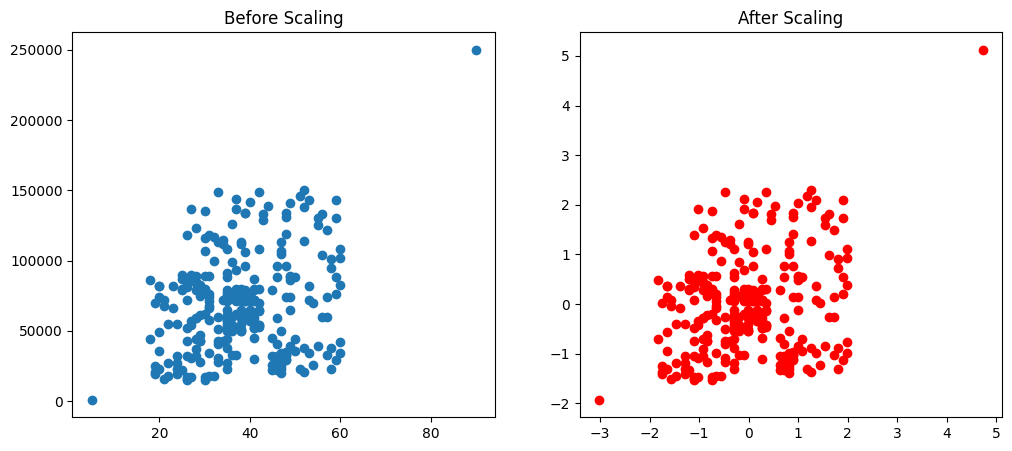

In [40]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

In [ ]:
# other standardization techniques

# min max scaling --- 
# mean normalization --- 
# max absolute scaling ---- 
# robust scaling  
# and many others see sklean documentation

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Data/wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']

In [3]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [ ]:
# min max scaling  --- converts scales values to min 0 and max 1
# x= (x-xmin)/(xmax - xmin)  --   new range [0,1]  -- shape same scale changed

<Axes: xlabel='Alcohol', ylabel='Density'>

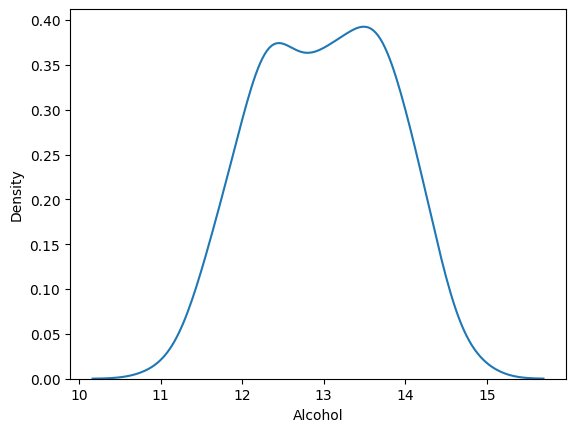

In [4]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

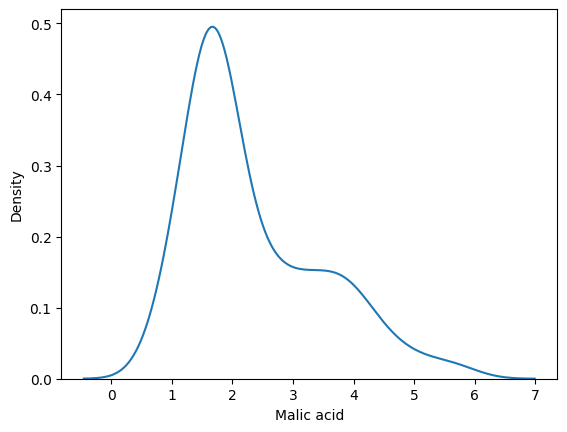

In [5]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

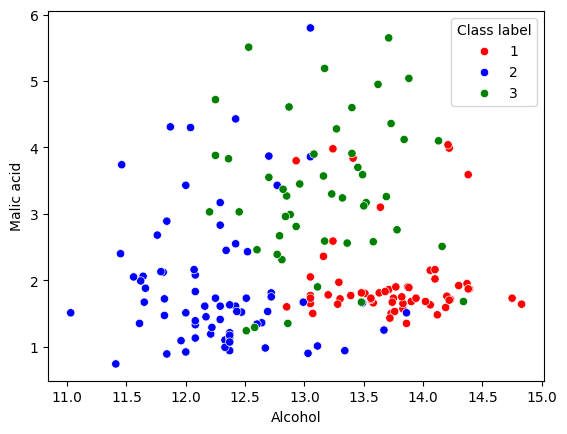

In [6]:
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(
    x='Alcohol',
    y='Malic acid',
    data=df,
    hue='Class label',
    palette=color_dict
)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1),
                                                    df['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [10]:
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [11]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


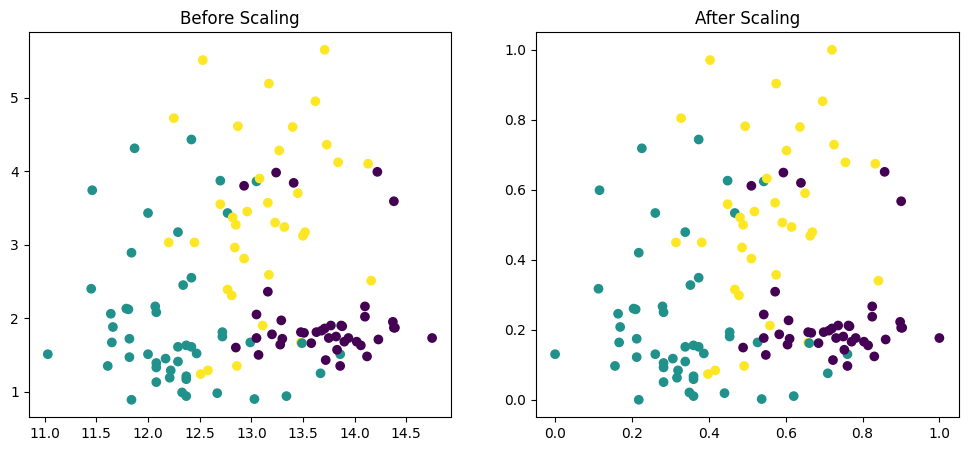

In [12]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

#just scaled changed shape same

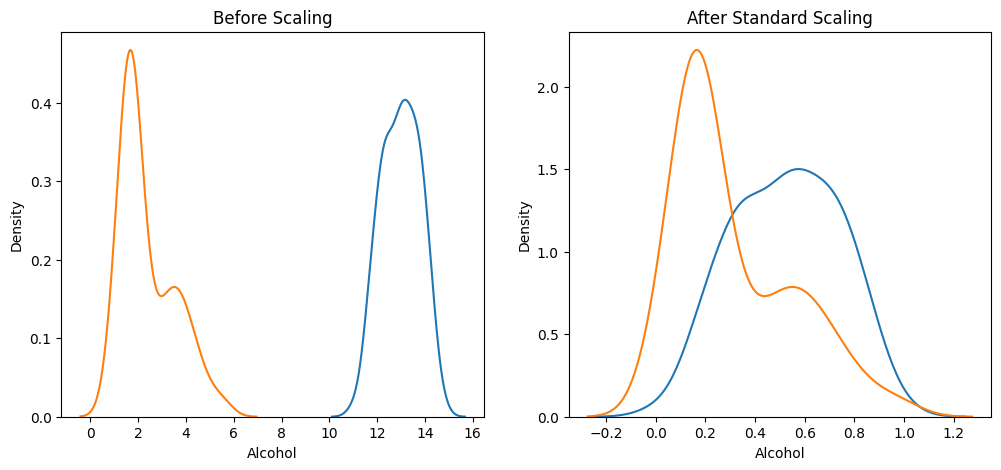

In [13]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

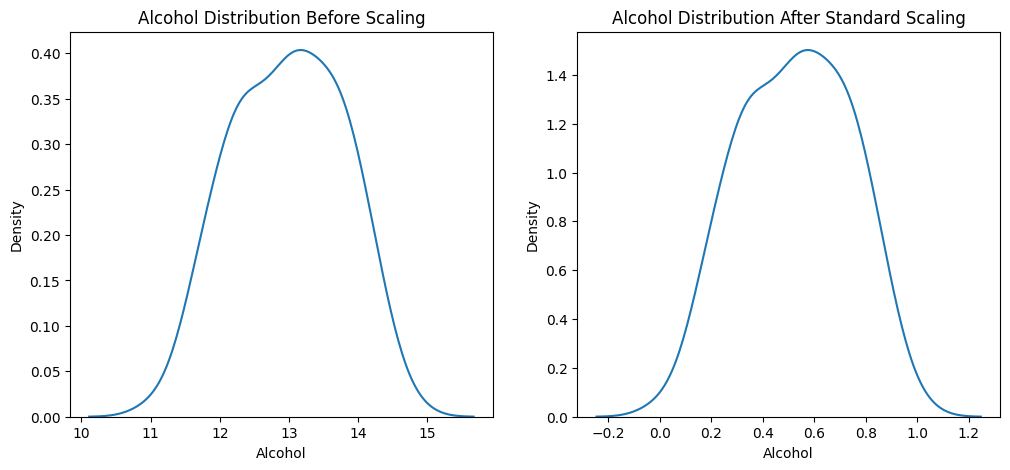

In [14]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

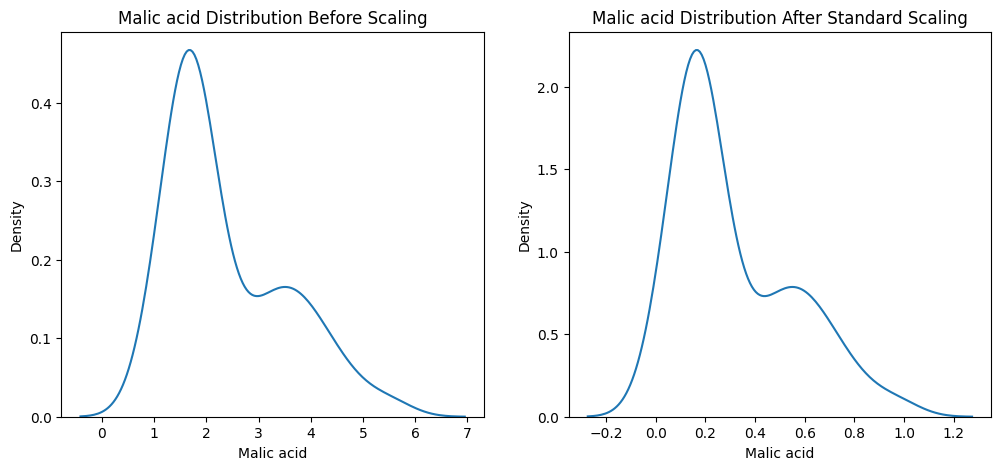

In [15]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

In [ ]:
# other standardization techniques

# mean normalization
# x=(x-xmean)/(xmax - xmin)    -- mean centering bringing mean to 0 on the C plain.  --- [-1,1] mean 0

#in sklean no class for mean mormalization so rarely used code write yourself no class given. useful for algo where you need centered 
# data. people use standardization instead of this bcz there also mean 0.

In [ ]:
# MaxAbScaling     --- ab value of Xmax  --- x=(x/ab Xmax)

#useful where sparse data alot of 0s
#not much used anywhere else
#used where signs of original values are important and should be preserved like financial data.

In [ ]:
#Robust Scaling  --- robust to outliers
#x=(x-xmedian)/IQR
# use if alot of outliers

In [ ]:
# now which one to use ???
# try all and see which results good then you will learn which use where.

# Part 2

In [ ]:
# part 2 numerical columns scaling

# Normalization  --- scales plus normalizes   -- when data not ND then use this scaling

# function transformer
# power transformer

In [ ]:
# sklean --- 
# function transformer  --- log transformer -- reciprocal -- sq/ sq root --- custom your own create code to convert to Normal distribution
# power transformer ---   box-cox --- yeo johnson ----
# quantile transformer ----


#function transformer --- we convert to normal distribution by removing like income of some very rich people that can be considered 
#                         outliers bcz they are few so transformations doesnt remove the essence of data.

# mathematical transformations in other words you are applying some mathematical formula on your columns and transforming them.

#transformation are done to improve model performance but the true essence of data is not lost.

#using these, the distributionss of data is converted to ND.

#some algo want ND so thats why use

#even you can build your own transformation logic the end goal is to get ND.

In [ ]:
# how to find if data is normal?
# sns.distplot
# pd.skew() = 0 normal
# QQ plot --- reliable way  45 degree angle graph -- if all points on this line ND.

In [ ]:
# log transform
# each value log. it get ND not completely. when use? dont use with -ve values. or use when right skewed data

# Reciprocal transform  1/x  --- 1 divide by x
# big values will become small -- small values big

#sq(x^2) transform 
# specially used for left skewed data

#sqrt(sqrtsign and inside x) transform ---- not much used but try all

In [ ]:
# without using function transformer -- check accuracy

import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('Data/train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [8]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2660\2888751792.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


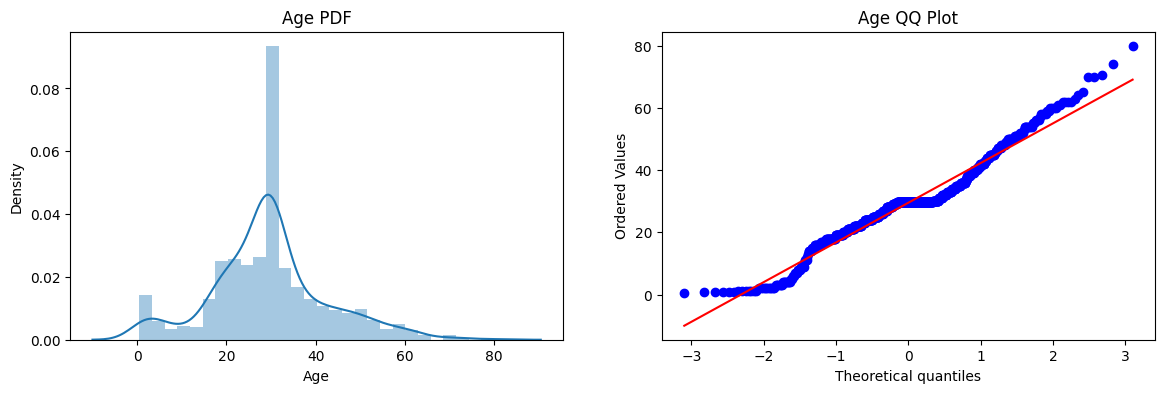

In [ ]:
# QQ plot to check if normal or not?

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2660\2981780686.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


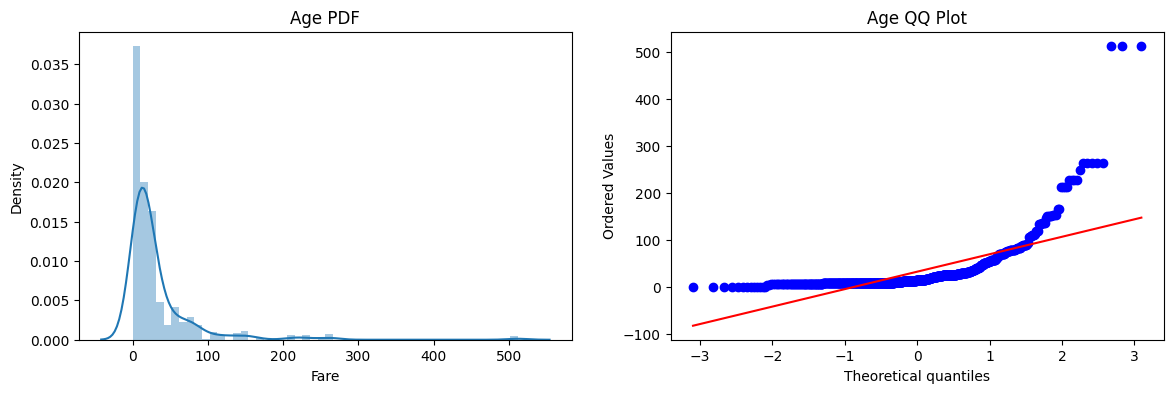

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()


# check fare column its right skewed bcz its right skewed to make it ND we will use log transformation

# 1st check without transformation if results not good then apply transform bcz we using linear model and transfor scaling important in LM

In [12]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [13]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
    
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6815642458100558


In [ ]:
# now with using function transformer
trf = FunctionTransformer(func=np.log1p)

# it adds +1 then does log to avoid 0 situation
# here you can give your own functions custom to convert to ND or use build in log sqrt etc

In [15]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [ ]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
    
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

#accuracy improved

Accuracy LR 0.6815642458100558
Accuracy DT 0.6927374301675978


In [17]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.655518102372035


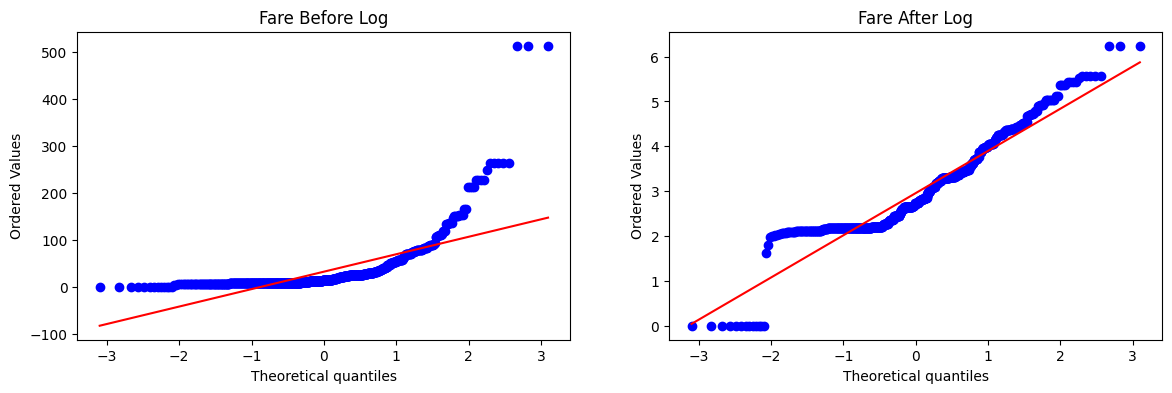

In [18]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

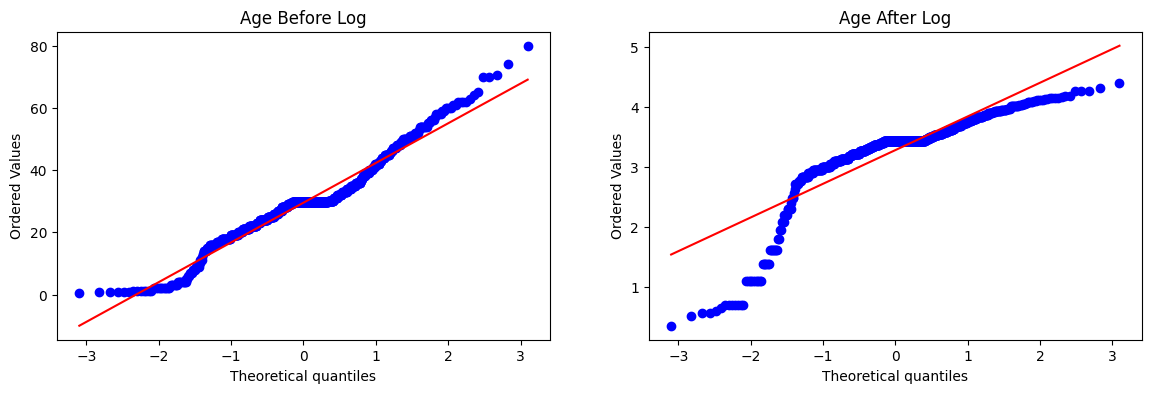

In [19]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [20]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [21]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.659217877094972


In [22]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6577153558052434


In [23]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()
    

Accuracy 0.6195131086142323


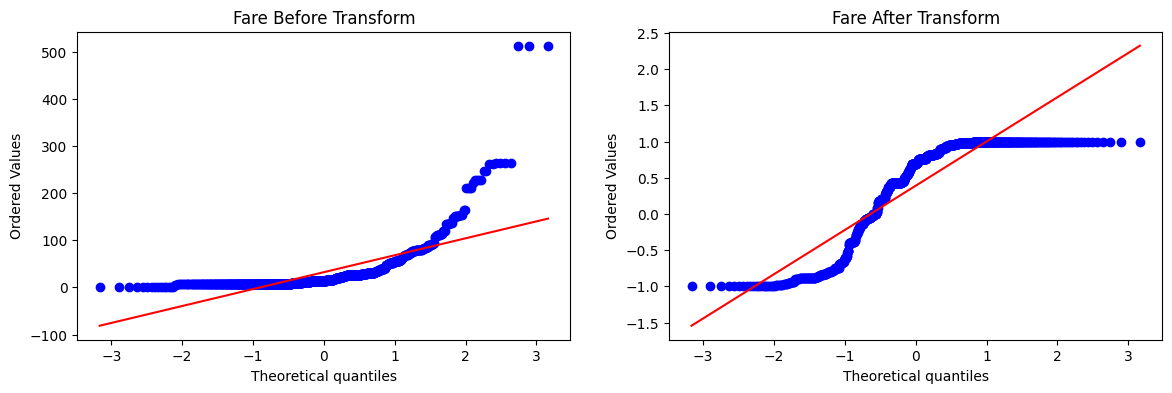

In [24]:
apply_transform(np.sin)

In [ ]:
# power transformer -

# function transformer can bring your data near to normal but power transformer can bring data to normal exactly. completely changes the distribution. but not essence.

# 1. box cox transformer  --- converts skewed to ND
# 2. yeo johnson transformer  -- converts skewed to ND
# 3. Quantile transformer  --- converts skewed,uniform,bimodel to Normal

# other normalization techniques for text data  -- 1. L2 normalization 2. L1 normalization

# 1. box cox transformer  maths --- n>0 only apply   -- 

# x power lamda = {[(x power lamda - 1)/lamda]    if lamda not equals to 0},     {[In(x) means natural log of x]     if lamda = 0}

# here you try to find the power that what will be the right power 2,3,4...   (-5 to 5) range

# the exponent here is a variable called lamda that varies over the range of -5 to 5 and in the process of searching we examine all values
# of lamda, finally we choose the optimal value (resulting in the best approximation to a normal distribution) for your variable.

# there are 2 techniques lamda find
# 1. max likelihood  2. bayesian statistics

# only applicable to #s n>0

# so this restriction solved by yeo johnson transformer

In [ ]:
# yeo johnson transformer

# this transformation is somewhat of an adjustment to the box cox transformation by which we can apply it to -ve numbers.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [3]:
df = pd.read_csv('Data/concrete_data.csv')

In [4]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [5]:
df.shape

(1030, 9)

In [6]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [ ]:
df.describe()     # to check if values 0 or -ve present or not bcz box cox will not work 

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [8]:
X = df.drop(columns=['Strength'])
y = df.iloc[:,-1]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# Applying Regression without any transformation and check result
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)

0.6275531792314848

In [ ]:
# Cross checking with cross val score     # cross val to validate the accuracy is correct or misleading
lr = LinearRegression()
np.mean(cross_val_score(lr,X,y,scoring='r2'))

np.float64(0.4609940491662864)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


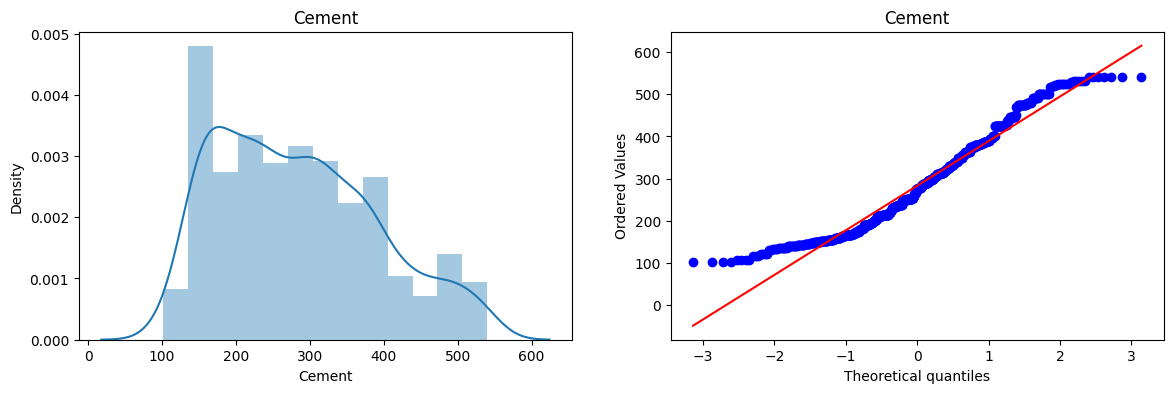

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


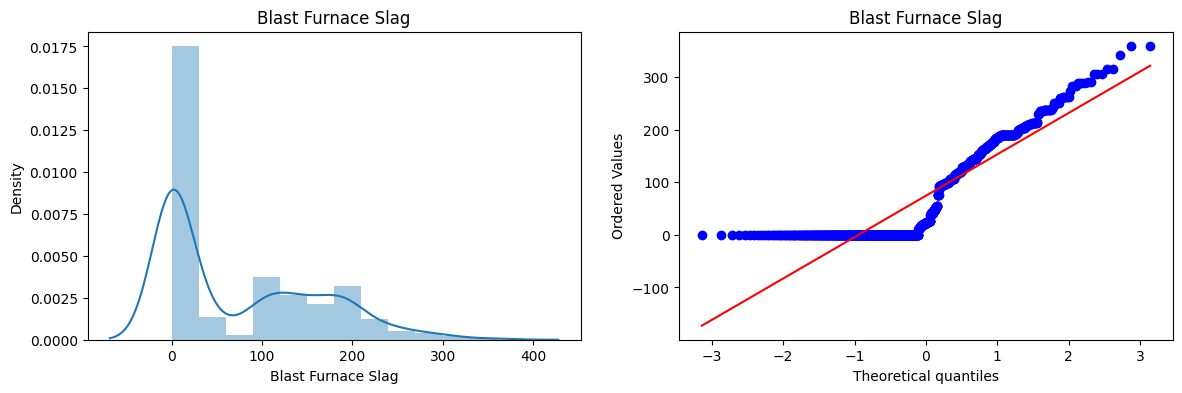

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


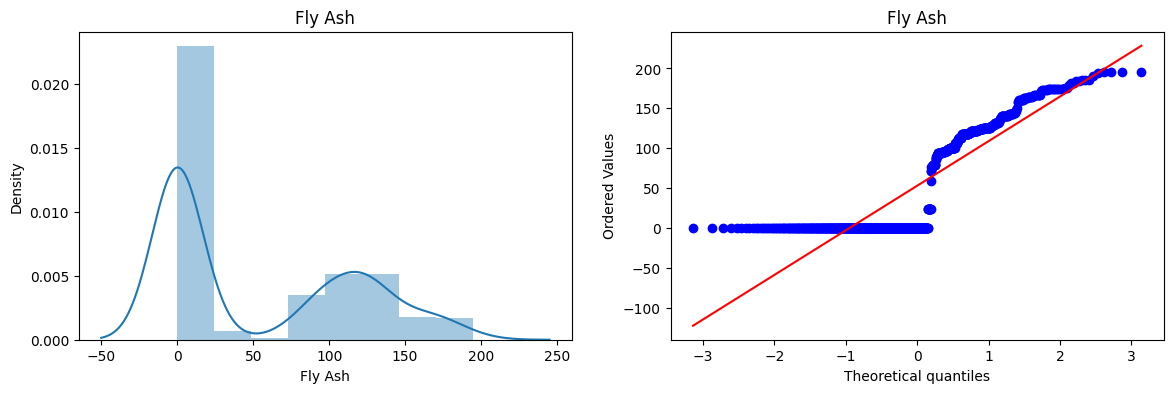

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


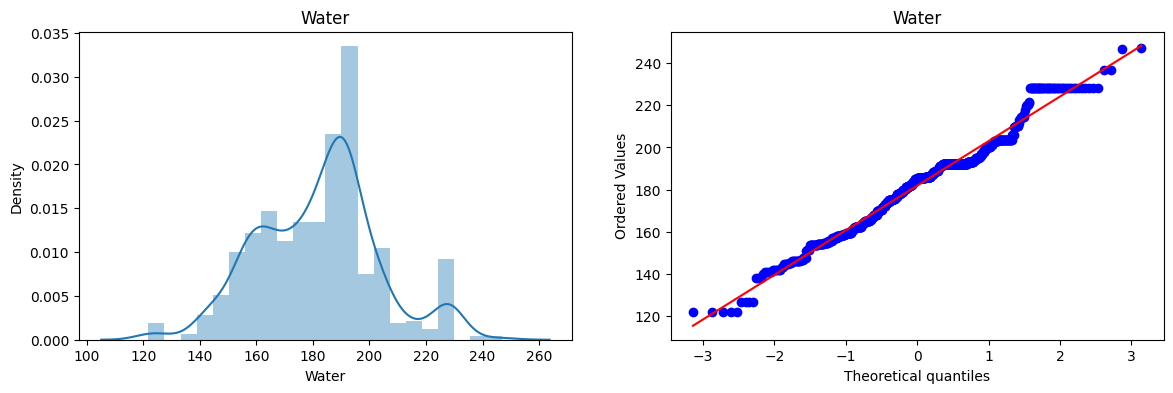

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


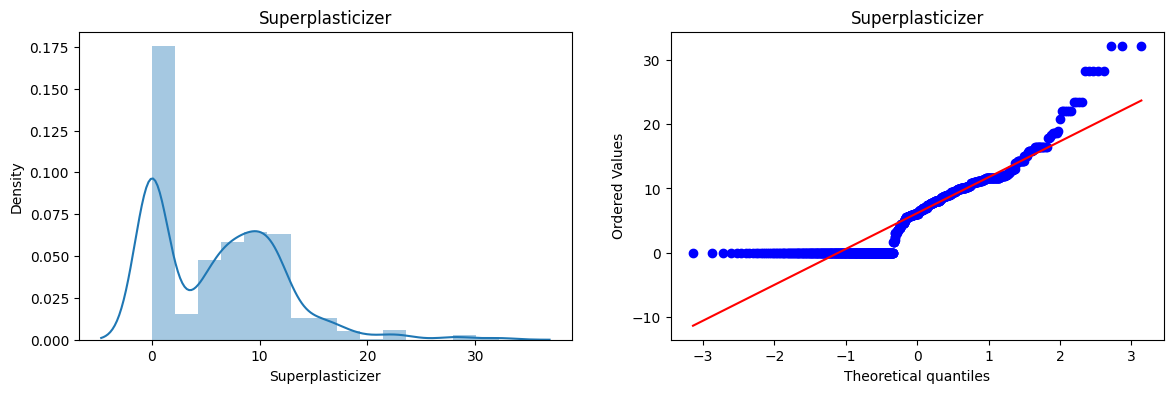

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


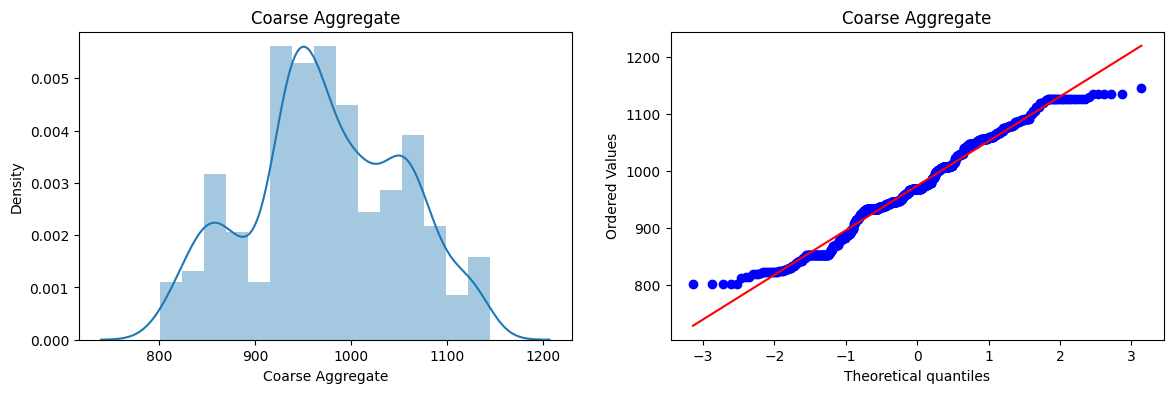

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


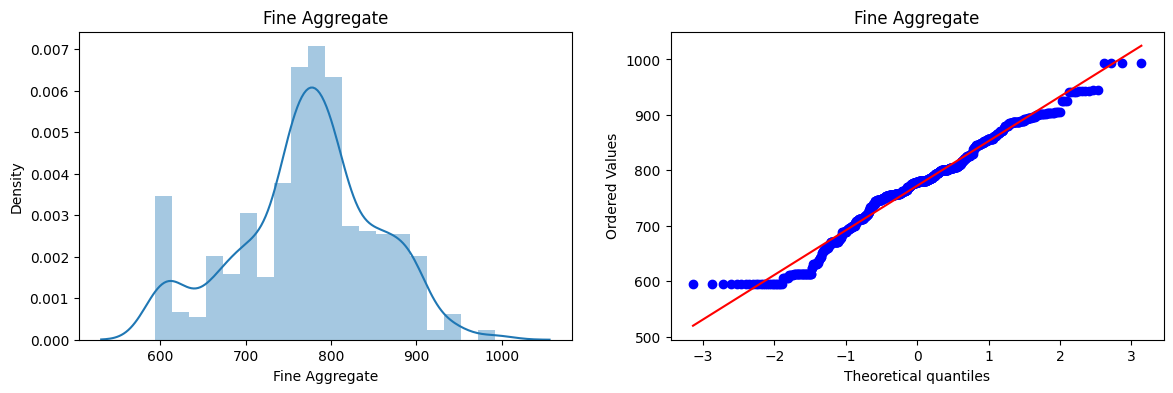

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


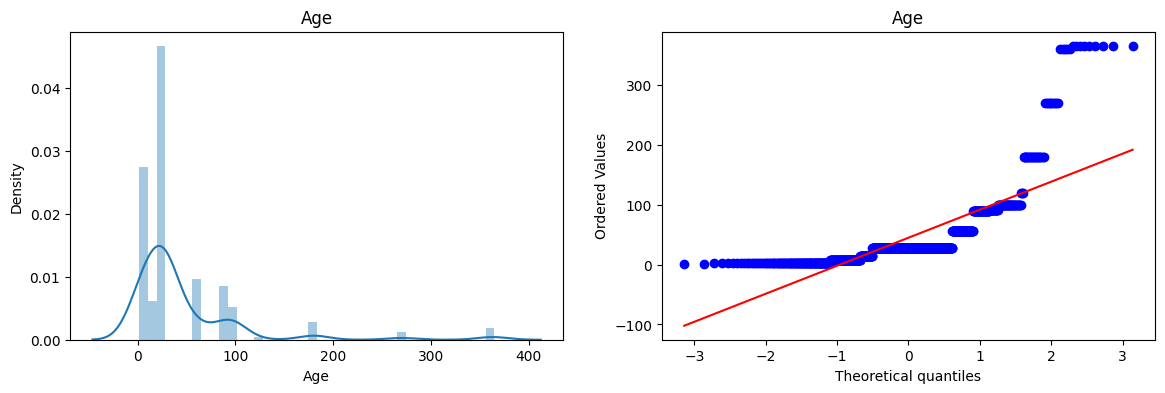

In [12]:
# Plotting the distplots without any transformation

for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [ ]:
# Applying Box-Cox Transform

pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})


#also can do scale but by default in this there is a parameter -- standardize:bool, default=True
#bcz 0 also to avoid that situation only apply to columns with not 0 or -ve values.
#or try this trick if you want to apply on col with 0   ---- add + 0.000001

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [14]:
# Applying linear regression on transformed data

lr = LinearRegression()
lr.fit(X_train_transformed,y_train)

y_pred2 = lr.predict(X_test_transformed)

r2_score(y_test,y_pred2)

0.8047825005397713

In [15]:
# Using cross val score

pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+0.0000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.6658537947024267)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


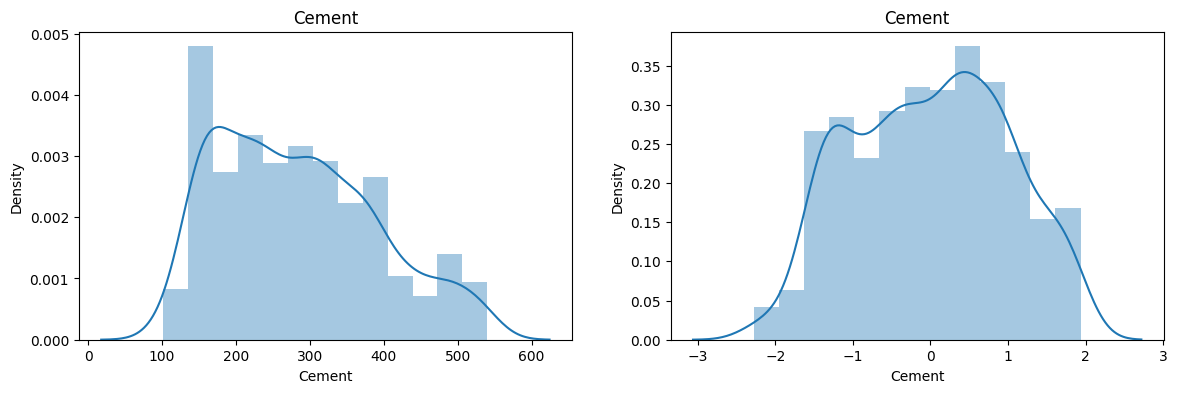

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


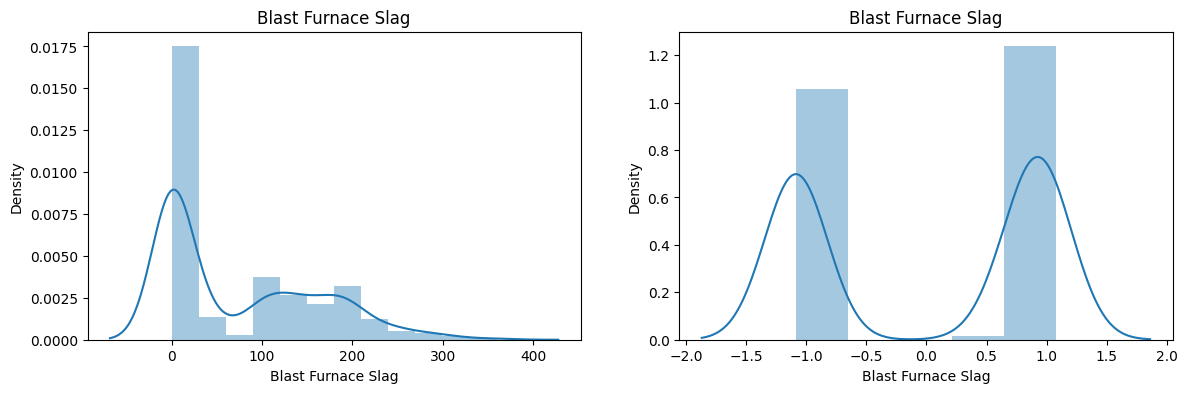

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


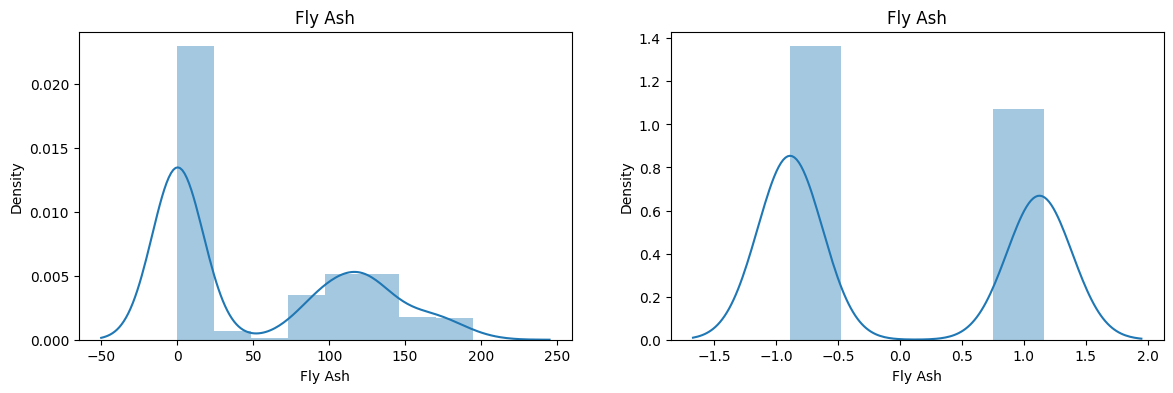

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


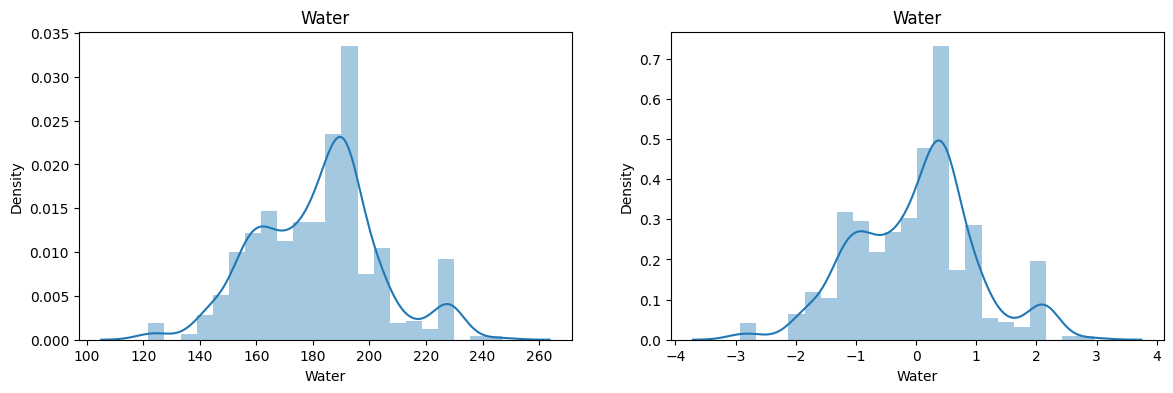

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


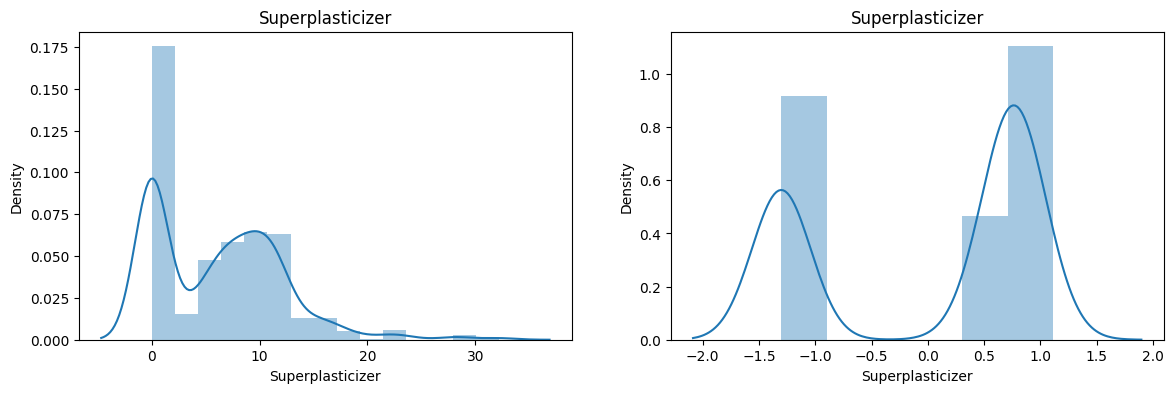

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


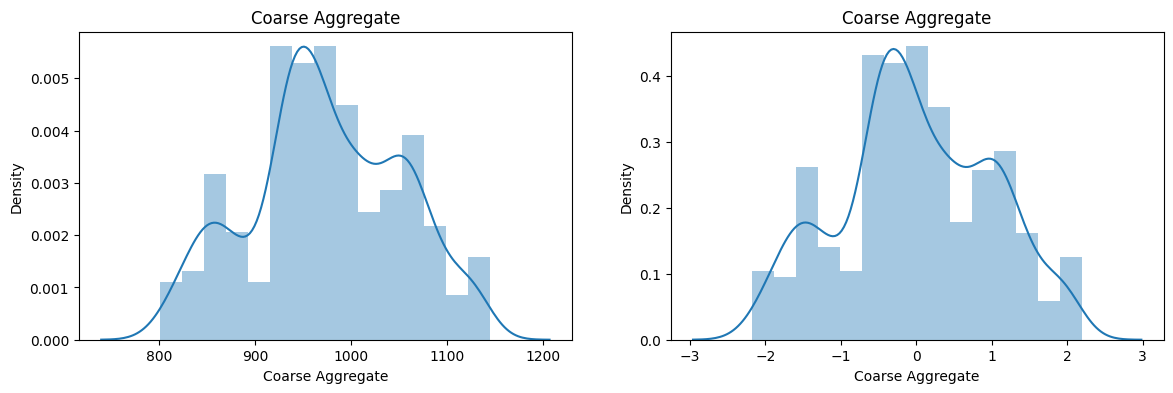

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


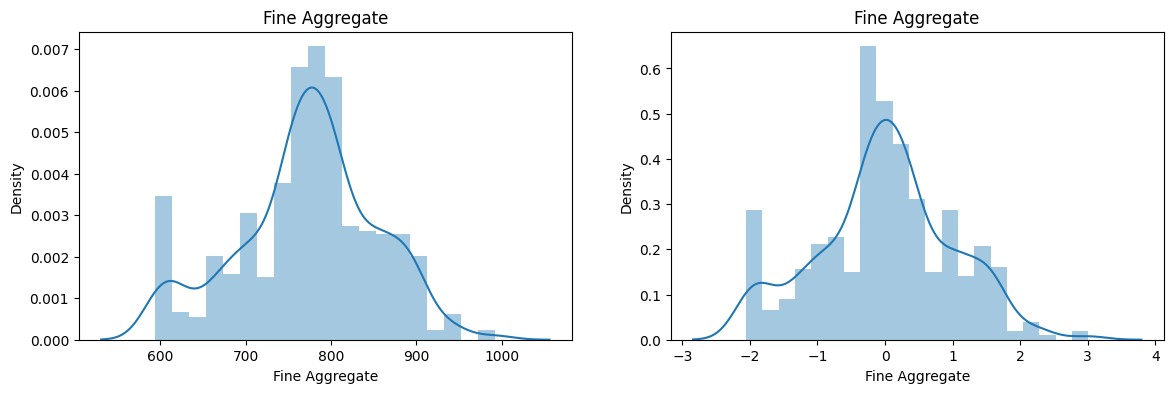

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1031937615.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


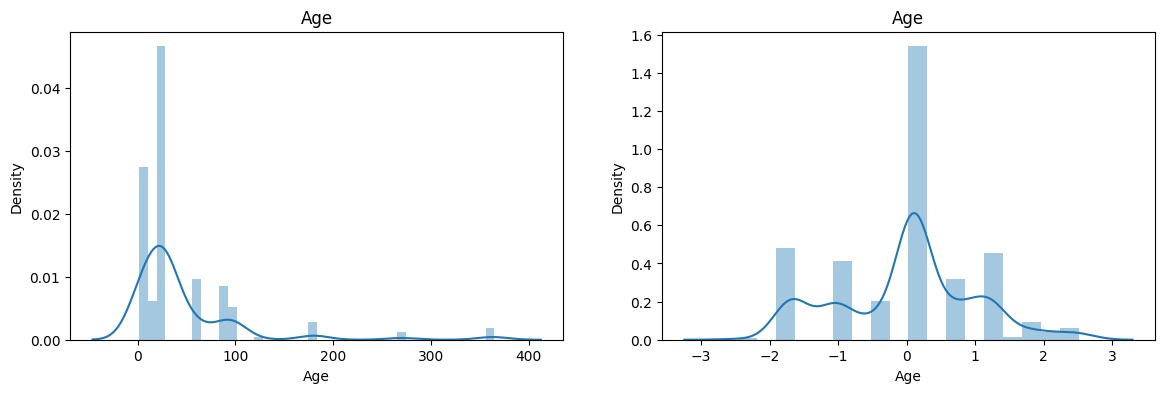

In [ ]:
# Before and after comparision for Box-Cox Plot
X_train_transformed = pd.DataFrame(X_train_transformed,columns=X_train.columns)

for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    sns.distplot(X_train_transformed[col])
    plt.title(col)

    plt.show()


#you can see before after plots --- distrubutions changed to ND. but essence not.

In [ ]:
# Apply Yeo-Johnson transform  ---- it can deal with 0 or -ve

pt1 = PowerTransformer()

X_train_transformed2 = pt1.fit_transform(X_train)
X_test_transformed2 = pt1.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed2,y_train)

y_pred3 = lr.predict(X_test_transformed2)

print(r2_score(y_test,y_pred3))

pd.DataFrame({'cols':X_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

0.8161906513339304


,cols,Yeo_Johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [18]:
# applying cross val score

pt = PowerTransformer()
X_transformed2 = pt.fit_transform(X)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed2,y,scoring='r2'))

np.float64(0.6834625134285748)

In [19]:
X_train_transformed2 = pd.DataFrame(X_train_transformed2,columns=X_train.columns)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed2[col])


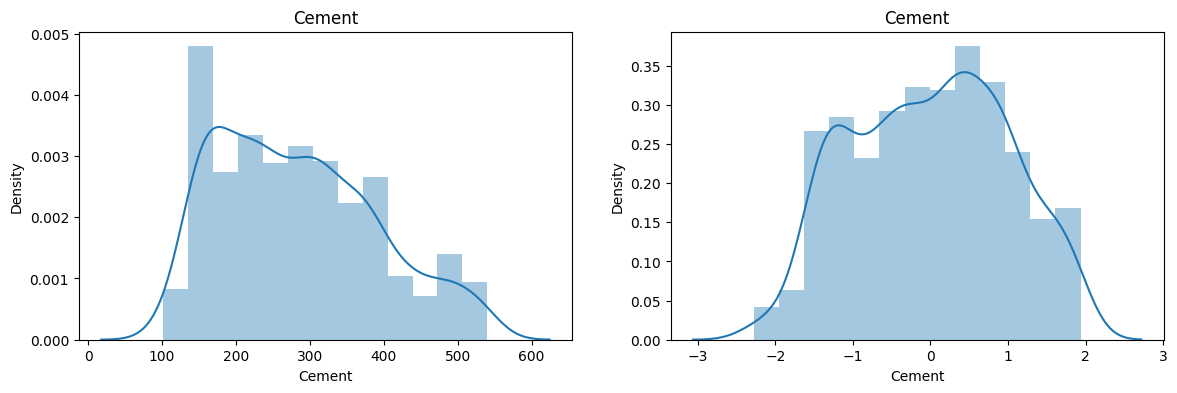

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed2[col])


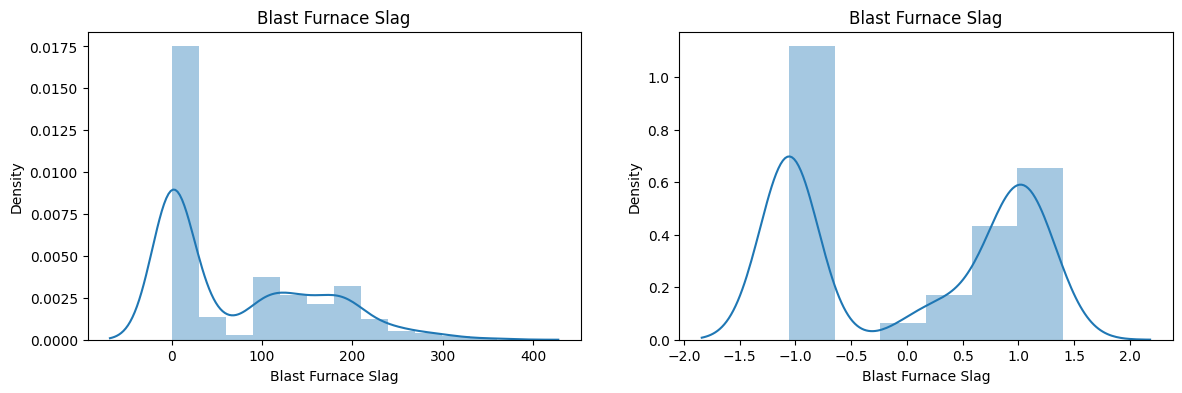

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed2[col])


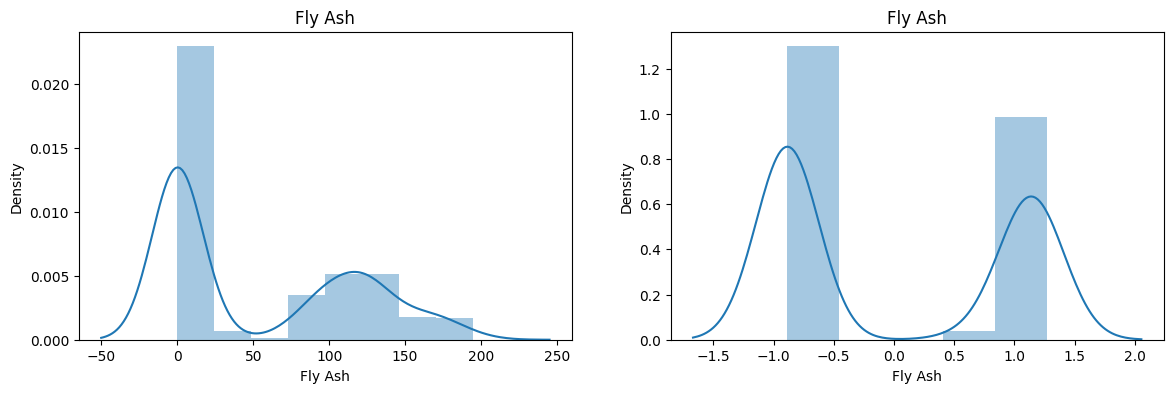

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed2[col])


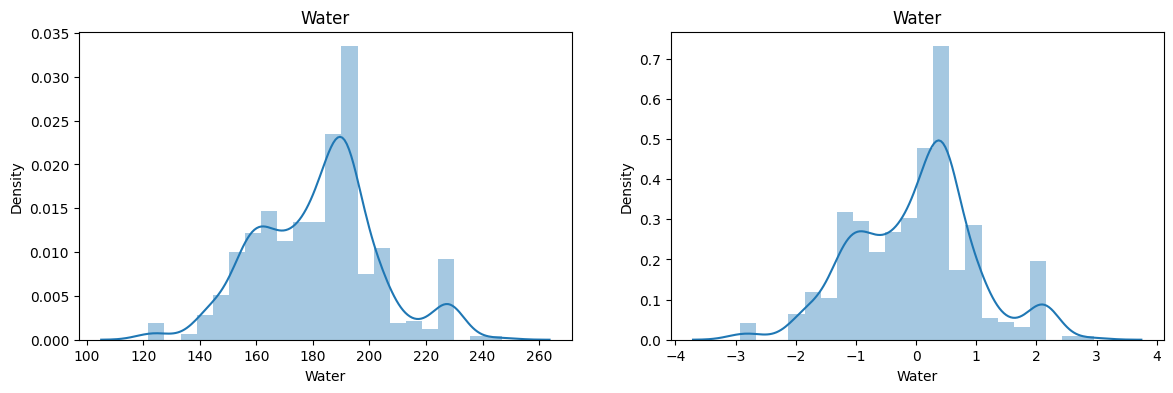

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed2[col])


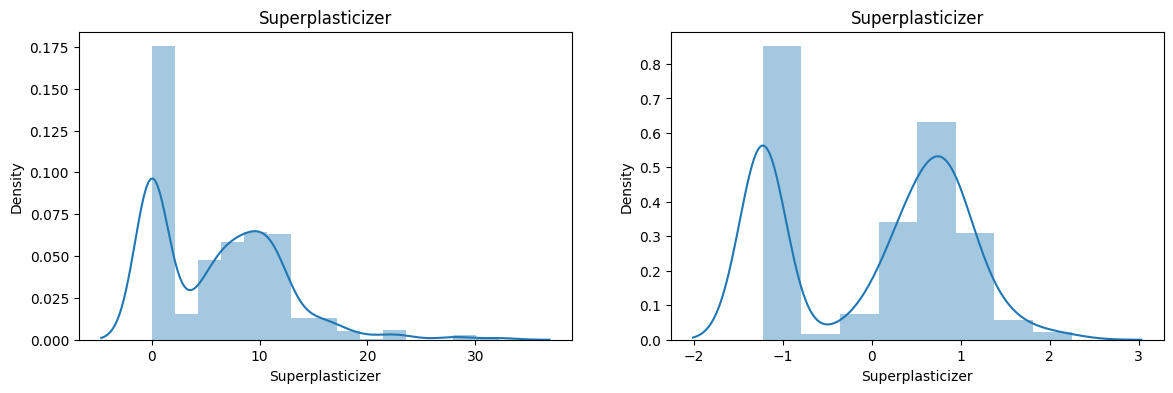

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed2[col])


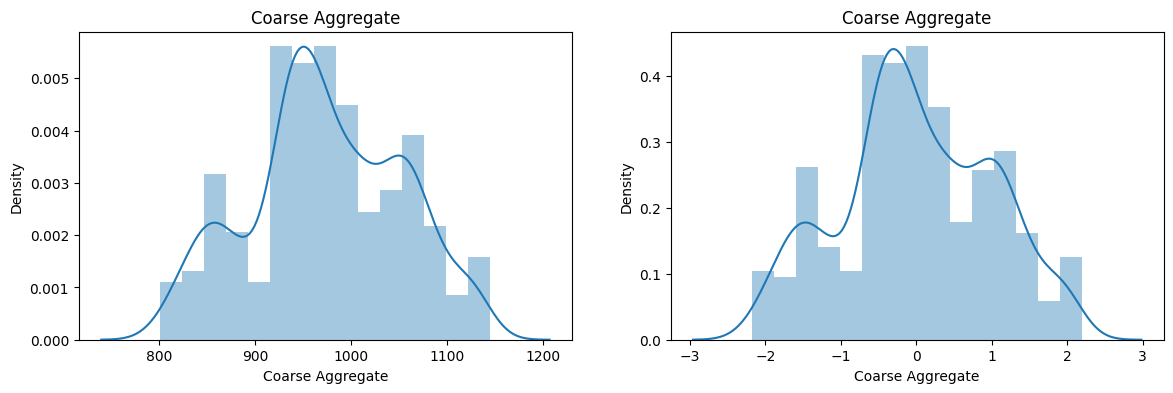

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed2[col])


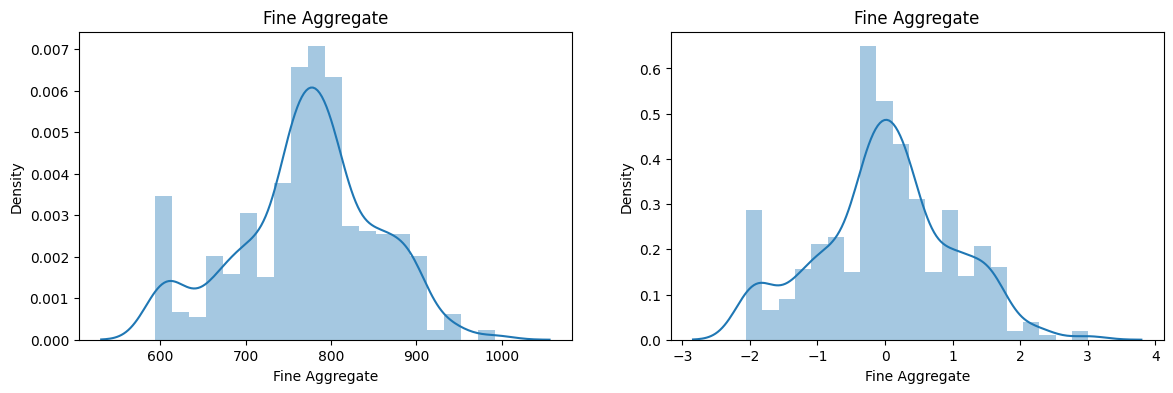

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13228\1516575210.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed2[col])


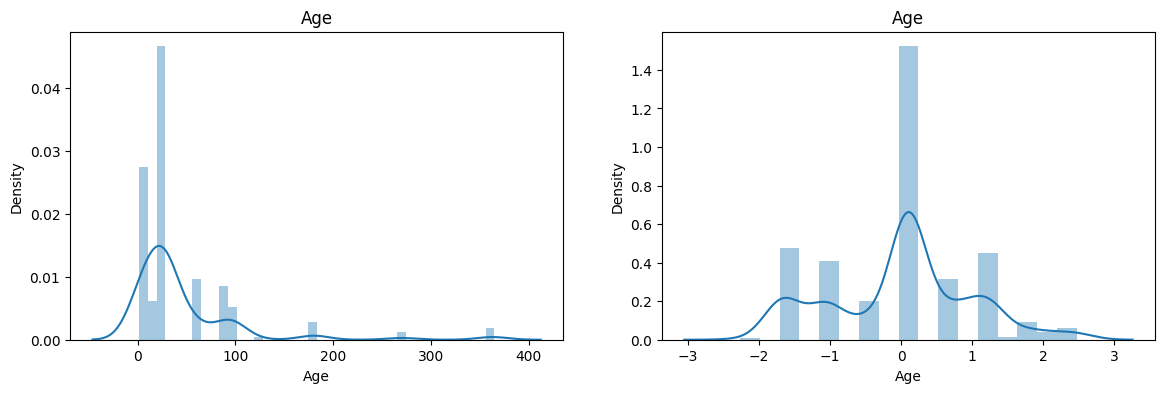

In [20]:
# Before and after comparision for Yeo-Johnson

for col in X_train_transformed2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    sns.distplot(X_train_transformed2[col])
    plt.title(col)

    plt.show()

In [21]:
# Side by side Lambdas
pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_,'Yeo_Johnson_lambdas':pt1.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,Cement,0.169544,0.174348
1,Blast Furnace Slag,0.016633,0.015715
2,Fly Ash,-0.136480,-0.161447
3,Water,0.808438,0.771307
4,Superplasticizer,0.264160,0.253935
5,Coarse Aggregate,1.129395,1.130050
6,Fine Aggregate,1.830763,1.783100
7,Age,0.001771,0.019885


In [ ]:
###### ultimately try all function transform as well as power transform and see which giving you best results.

# Part 3

In [ ]:
# numerical columns are scaled for machine to understand it. while cat are encoded.

# categorical data -- encoded 

In [ ]:
# Encoding categorical data
# Ordinal encoding
# Label encoding
# one hot encoding

# categorical data 
# Nominal[no order -- states,gender,yes/no] --- 
# Ordinal data[order --- review, education levels]

# ordinal encoding [for ordinal data] like low medium high 1 2 3
# label encoding [similar to ordinal but used for output y in classification problems]
# one hot encoding [nominal data]  each value count created as sep column and 000111 used.


# for x categorical variables ---- ordinal encoder used   or   one hot

# other --- frequency/count [use if categorical feature has large # unique values high cardinality bcz one hot can be problem then]
#                           also dont use it if categories count same or loss of info(each category importance in itself) 

# other --- binary encoder

In [ ]:
# Ordinal encoding
# check if nominal or ordinal if ordinal then only use ordinal 
# like education levels --- post graduate 2  --- graduate 1 ---- high school 0
# also always do 1st train test split then transform[encode]

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('Data/customer.csv')

In [3]:
df.sample(5)

,age,gender,review,education,purchased
25,57,Female,Good,School,No
27,69,Female,Poor,PG,No
13,57,Female,Average,School,No
28,48,Male,Poor,School,No
8,65,Female,Average,UG,No


In [4]:
df = df.iloc[:,2:]

In [5]:
df.head()

,review,education,purchased
0,Average,School,No
1,Poor,UG,No
2,Good,PG,No
3,Good,PG,No
4,Average,UG,No


In [6]:
from sklearn.preprocessing import OrdinalEncoder

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('purchased', axis=1),
                                                    df['purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((35, 2), (15, 2))

In [ ]:
#X_train

In [ ]:
oe = OrdinalEncoder(categories=[['Poor','Average','Good'],['School','UG','PG']])  # here we giving it in order -- poor avg good so it give them order bcz its ordinal data

In [ ]:
oe.fit(X_train)           # fit only on train data not test data --- tehn tranform on both test train

OrdinalEncoder(categories=[['Poor', 'Average', 'Good'], ['School', 'UG', 'PG']])

In [14]:
X_train = oe.transform(X_train)

In [15]:
X_train

array([[0., 0.],
       [0., 2.],
       [0., 2.],
       [2., 1.],
       [1., 1.],
       [0., 1.],
       [1., 1.],
       [1., 1.],
       [0., 1.],
       [2., 2.],
       [1., 0.],
       [0., 2.],
       [1., 1.],
       [1., 0.],
       [2., 0.],
       [1., 0.],
       [0., 1.],
       [2., 0.],
       [2., 1.],
       [0., 1.],
       [0., 0.],
       [1., 2.],
       [1., 2.],
       [2., 0.],
       [2., 0.],
       [2., 1.],
       [1., 2.],
       [0., 2.],
       [2., 1.],
       [0., 2.],
       [0., 2.],
       [2., 2.],
       [1., 0.],
       [2., 2.],
       [1., 1.]])

In [16]:
oe.categories_

[array(['Poor', 'Average', 'Good'], dtype=object),
 array(['School', 'UG', 'PG'], dtype=object)]

In [18]:
X_test

,review,education
28,Poor,School
11,Good,UG
10,Good,UG
41,Good,PG
2,Good,PG
27,Poor,PG
38,Good,School
31,Poor,School
22,Poor,PG
4,Average,UG


In [19]:
X_test = oe.transform(X_test)

In [20]:
X_test

array([[0., 0.],
       [2., 1.],
       [2., 1.],
       [2., 2.],
       [2., 2.],
       [0., 2.],
       [2., 0.],
       [0., 0.],
       [0., 2.],
       [1., 1.],
       [2., 2.],
       [0., 0.],
       [0., 2.],
       [1., 0.],
       [2., 0.]])

In [21]:
#       label encoder    same as ordinal encoder but used for y output values in classification problem
from sklearn.preprocessing import LabelEncoder


In [22]:
le = LabelEncoder()

In [23]:
y_train.head()

7     Yes
14    Yes
45    Yes
48    Yes
29    Yes
Name: purchased, dtype: object

In [24]:
le.fit(y_train)

LabelEncoder()

In [25]:
le.classes_

array(['No', 'Yes'], dtype=object)

In [26]:
y_train = le.transform(y_train)
y_test = le.transform(y_test)

In [27]:
y_train

array([1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0])

In [ ]:
# one hot encoding

# for nominal data

# let yellow blue and red  ---- so 3 columns 1 0 0 --- 0 1 0 ---- 0 0 1  but we remove 1 if 3 there so 2 column left -- if both are 0 0 that means they are talking about third
# n  ----  n minus 1 ----  why remove? multicolinearity -- input columns should be independent to each other thats why we remove 1  --- dummy variable trap

In [ ]:
# other --- frequency/count [use if categorical feature has large # unique values high cardinality bcz one hot can be problem then]
#                           also dont use it if categories count same or loss of info(each category importance in itself) 

# other --- binary encoder

In [ ]:
# frequency encoding

# let brand includes many things --- maruti skoda honda hyundai maruti up to 40 different brands  -- here one hot encoding will problem
# high cardinality -- in such case we do 1. keep the most frequent categories 2. and the ones that are very less frequent we convert them
# -- to a new category let say 'others'ArithmeticError
# so then you will be left with 10 categories instead of 40.
# only use this approach if some categories ery frequent and some very very less.

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('Data/cars.csv')

In [3]:
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [4]:
df['owner'].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

In [ ]:
# OneHotEncoding using Pandas

In [5]:
pd.get_dummies(df,columns=['fuel','owner'])

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,False,True,False,False,True,False,False,False,False
1,Skoda,120000,370000,False,True,False,False,False,False,True,False,False
2,Honda,140000,158000,False,False,False,True,False,False,False,False,True
3,Hyundai,127000,225000,False,True,False,False,True,False,False,False,False
4,Maruti,120000,130000,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,False,True,True,False,False,False,False
8124,Hyundai,119000,135000,False,True,False,False,False,True,False,False,False
8125,Maruti,120000,382000,False,True,False,False,True,False,False,False,False
8126,Tata,25000,290000,False,True,False,False,True,False,False,False,False


In [ ]:
pd.get_dummies(df,columns=['fuel','owner'],drop_first=True)   #if 3 categories keep 2 remove 1. bcz if both will be 0 0 that means they talking about third one

#remove 1st column to avoid multicolinearity

#in ML project we dont use pandas get dummies bcz it doesnt remembers which columns it placed in what position. so use sklearn onehot

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,True,False,False,False,False,False,False
1,Skoda,120000,370000,True,False,False,False,True,False,False
2,Honda,140000,158000,False,False,True,False,False,False,True
3,Hyundai,127000,225000,True,False,False,False,False,False,False
4,Maruti,120000,130000,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,True,False,False,False,False
8124,Hyundai,119000,135000,True,False,False,True,False,False,False
8125,Maruti,120000,382000,True,False,False,False,False,False,False
8126,Tata,25000,290000,True,False,False,False,False,False,False


In [ ]:
# OneHotEncoding using Sklearn

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:4],df.iloc[:,-1],test_size=0.2,random_state=2)

In [8]:
X_train.head()

,brand,km_driven,fuel,owner
5571,Hyundai,35000,Diesel,First Owner
2038,Jeep,60000,Diesel,First Owner
2957,Hyundai,25000,Petrol,First Owner
7618,Mahindra,130000,Diesel,Second Owner
6684,Hyundai,155000,Diesel,First Owner


In [10]:
from sklearn.preprocessing import OneHotEncoder


In [ ]:
ohe = OneHotEncoder(drop='first', sparse_output=False, dtype=np.int32)  # dtype int32 means your category will be integer not float. 

#sparse output false means bcz it creates spare alot of 0s so we said false. added so ouput of onehot will be array not sparse matrix bcz onehot creates sparse matrix

In [13]:
X_train_new = ohe.fit_transform(X_train[['fuel','owner']])

In [14]:
X_test_new = ohe.transform(X_test[['fuel','owner']])

In [15]:
X_train_new.shape

(6502, 7)

In [ ]:
# now lets see how to deal with columns like brand alot of categories 
# take a threshold let 100 if less than this value_counts those will go in others

In [16]:
np.hstack((X_train[['brand','km_driven']].values,X_train_new))

array([['Hyundai', 35000, 1, ..., 0, 0, 0],
       ['Jeep', 60000, 1, ..., 0, 0, 0],
       ['Hyundai', 25000, 0, ..., 0, 0, 0],
       ...,
       ['Tata', 15000, 0, ..., 0, 0, 0],
       ['Maruti', 32500, 1, ..., 1, 0, 0],
       ['Isuzu', 121000, 1, ..., 0, 0, 0]], dtype=object)

In [ ]:
# OneHotEncoding with Top Categories

In [17]:
counts = df['brand'].value_counts()

In [18]:
df['brand'].nunique()
threshold = 100

In [ ]:
repl = counts[counts <= threshold].index

#categories whose counts are less than 100 take out them and save in variable rep1

In [ ]:
pd.get_dummies(df['brand'].replace(repl, 'uncommon')).sample(5)

#if ML project then use sklearn onehot 

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,uncommon
4552,False,False,False,False,True,False,False,False,False,False,False,False,False
5427,False,True,False,False,False,False,False,False,False,False,False,False,False
7482,False,False,False,False,True,False,False,False,False,False,False,False,False
1258,False,False,False,False,False,False,True,False,False,False,False,False,False
5393,False,False,False,False,False,False,True,False,False,False,False,False,False


# Part 4

In [ ]:
# binning
# countinous to categorical   convert 
# used when deal with outliers
#

In [ ]:
#extra 

#kBinDiscretizer(n_bins=5,encode='ordinal',strategy='uniform')
#sklearn -- kBinsDiscretizer   3 parameters -- 1.bins#? 2.strategy?uniform?quantile?k means?------- 3. encoding(1.ordinal 2.onehot encoding)tell the bin#in which the value putted.

#cut
#used to specifically define bin edges 
#bins=[0,10,18,30,50,80]  -- labels=['child','teenager',...]  -- df['age_bin']=pd.cut(df['age'],bins=bins,labels=labels)
# df['column'].max()  ----  df['column'].min()   --- .nunique() then you will get idea how many bins to create and what size

#qcut
#use if want equal dist of items in your bin
#df['newcolumn']=pd.qcut(df['column'],q=4)   a new categorical column will be created from numeric ---- only labels we can set in qcut not distribution

In [ ]:
#numeric to categorical --- sometimes needed for example google playstore data no of downloads of diff apps label as 100+ 1000+ 1M+ ..
#such things will not look good so convert to categorical

#2 techniques 
# 1. discretization binning 
# 2. binarization

#discretization --- process of transforming continuous variables into discrete variables by creating a set of contiguous intervals that
#                   span the range of the variables values.

#why use discretization? benefits --- 1.to handle outliers 2. to improve the value spread
#age -- 23 42 57 81 --- 100   -------- 0-10, 10-20, 20-30, ..... bins/intervals

# types of discretization or binning 
# unsupervised binning ---- 1.equal width binning uniform binning 2. equal frequency binning quantile binning 3.kmeans binning.
# supervised binning --- 1. decision tree binning 
# custom binning

In [ ]:
# unsupervised binning ---- 1.equal width binning uniform binning -- intervals same in all bins

#let age 27,32,84,56,.....   tell how many bins you want?  bins=10
#(max-min)/bins ----- (100-0)/10 ==10 ---- let max 100, min 0, bins 10  
#so intervals will be of 10 and total bins = 10
#(0-10),(10-20),(20-30),...(90-100)
#bcz intervals same in all bins thats why called equal width/uniform binning.
#benefits-- 1.outliers handled 2.no change in spread(distribution)

In [ ]:
#2. equal frequency binning quantile binning

#tell # of bins you want? 10
#each interval contains 10% of total observations
#intervals: 0-16,16-20,20-22,22-25,...
#0 to that value where 10th percentile value then next 10th percentile value then next...
#not important that width will be equal in all intervals. but how many items in that, that will remain similar.
#0-16   16-20    20-22...
#10th percen  -- 20th  --- 30th -- ...
#mostly used compared to previous one
#benefits -- 1.works good with outliers.   2. value spread ko uniform banata hay. bcz har interval may barabar items 
#                                              aty hay. tou histogram uniform banta hay. same heigh sab bars kay.

In [ ]:
#3.kmeans binning.

#you use a clustering algorithm k means.
#only used when your data spread is like clusters with distance from each other. otherwise use others.
#tell # of intervals/centroids = let 5
#it ramdomly creates 5 centroids then it gets adjusted/corrects itself and clusters formed.
#after random centers then lines to bisect each cluster. each point distance calculated from every all centroids. the near
#                                                        that point point is with a centroid it will go in that.
#after that centroids move to the center of points around it ... this process will continue untill movement of center not required any more.
#only use when data spread like cluster dont use otherwise.



#sklearn -- kBinsDiscretizer   3 parameters -- 
# 1.bins#? 
# 2.strategy?uniform?quantile?k means?------- 
#3. encoding(1.ordinal 2.onehot encoding)tell the bin#in which the value putted.

In [ ]:
#!pip install pandas

In [4]:
#code
import pandas as pd
import numpy as np

In [ ]:
#pip install matplotlib
#!pip install scikit-learn

In [10]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [11]:
df = pd.read_csv('Data/train.csv',usecols=['Age','Fare','Survived'])

In [12]:
df.dropna(inplace=True)

In [13]:
df.shape

(714, 3)

In [14]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [15]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [18]:
clf = DecisionTreeClassifier()

In [19]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [20]:
accuracy_score(y_test,y_pred)

0.6083916083916084

In [21]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6317097026604068)

In [22]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [ ]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),   # 0 there is column number 
    ('second',kbin_fare,[1])
])

In [24]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

d:\Python_SQL_2025\EDA_Statistics_Projects_Python\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Python_SQL_2025\EDA_Statistics_Projects_Python\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [ ]:
trf.named_transformers_['first'].bin_edges_         #10% values lies in each interval

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [26]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [ ]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

#dataframe create #this is just to see the bins no other work.

In [28]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [ ]:
output.sample(5)

#encoded bin # of the age/fare

,age,age_trf,fare,fare_trf,age_labels,fare_labels
688,18.0,2.0,7.7958,2.0,"(16.0, 19.0]","(7.775, 7.896]"
338,45.0,12.0,8.0500,3.0,"(42.0, 47.0]","(7.896, 8.158]"
58,5.0,0.0,27.7500,10.0,"(0.42, 6.0]","(26.55, 31.275]"
380,42.0,12.0,227.5250,14.0,"(38.0, 42.0]","(108.9, 512.329]"
873,47.0,13.0,9.0000,4.0,"(42.0, 47.0]","(8.158, 10.5]"


In [ ]:
#model and check accuracy

clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [31]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [32]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

d:\Python_SQL_2025\EDA_Statistics_Projects_Python\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Python_SQL_2025\EDA_Statistics_Projects_Python\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6232394366197183)

In [33]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

0.6373043818466353


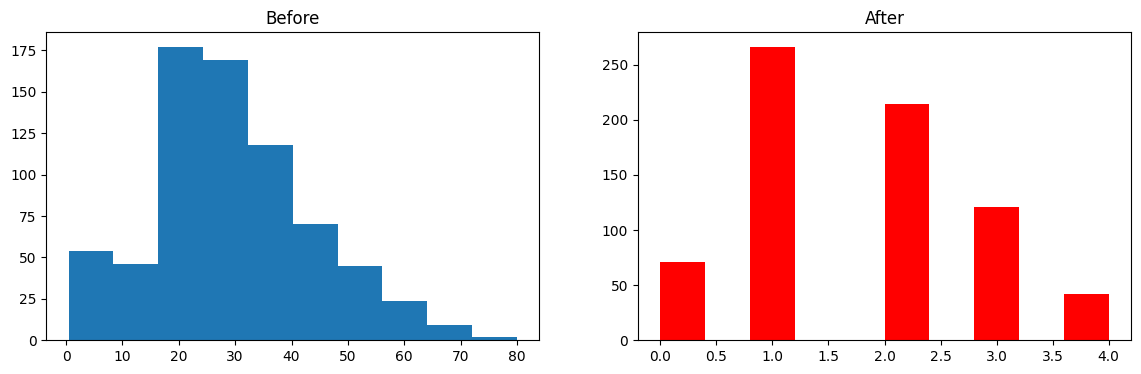

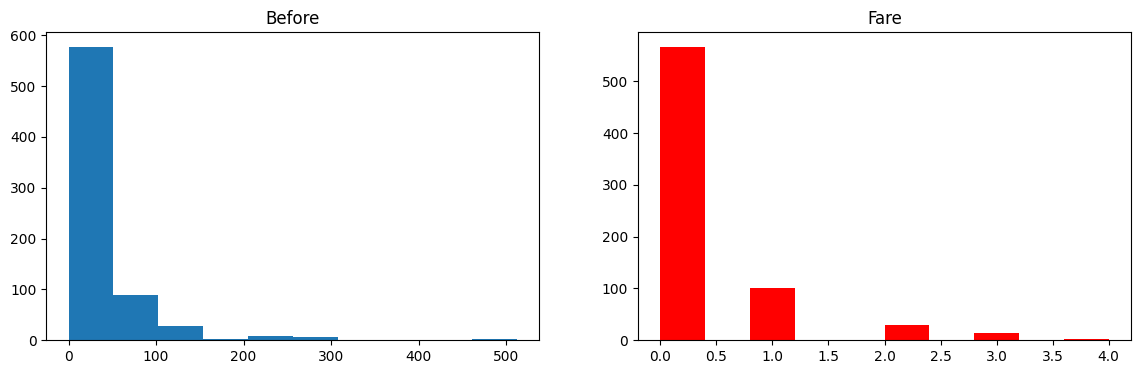

In [34]:
discretize(5,'kmeans')

In [ ]:
######### custom/domain based binning
#your own choice bins
#0-18  kids   18-60 --- .....
#pandas use  ------------------- qcut --- cut

In [ ]:
#supervised binning --- 1. decision tree binning 
# custom binning

In [ ]:
########## 2 techniques
# 1. binning/discretization   ------ continous to discrete
# 2.binarization------------ continous to binary(0,1) --- like if annual income if < 6L -- no tax -- 0 but if > -- tax -- 1

In [ ]:
# 2.binarization 
#use case image -- color image --- to black/white
#let 0-255  --- [>27.5 pixel values -- 0 black] [<127.5  -- 1 white]
#sklearn --- binarizer -- threshold 127.5 let --- copy = true --- it will create a new column,if false it will make changes
#                                                                 to existing column no new created.  

In [1]:
# 2.binarization 
import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('Data/train.csv')[['Age','Fare','SibSp','Parch','Survived']]

In [4]:
df.dropna(inplace=True)

In [5]:
df.head()

,Age,Fare,SibSp,Parch,Survived
0,22.0,7.2500,1,0,0
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,1
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,0


In [6]:
df['family'] = df['SibSp'] + df['Parch']

In [7]:
df.head()

,Age,Fare,SibSp,Parch,Survived,family
0,22.0,7.2500,1,0,0,1
1,38.0,71.2833,1,0,1,1
2,26.0,7.9250,0,0,1,0
3,35.0,53.1000,1,0,1,1
4,35.0,8.0500,0,0,0,0


In [8]:
df.drop(columns=['SibSp','Parch'],inplace=True)

In [9]:
df.head()

,Age,Fare,Survived,family
0,22.0,7.2500,0,1
1,38.0,71.2833,1,1
2,26.0,7.9250,1,0
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [10]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
X_train.head()

,Age,Fare,family
328,31.0,20.5250,2
73,26.0,14.4542,1
253,30.0,16.1000,1
719,33.0,7.7750,0
666,25.0,13.0000,0


In [13]:
# Without binarization

clf = DecisionTreeClassifier()

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test,y_pred)

0.6293706293706294

In [14]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.645735524256651)

In [ ]:
# Applying Binarization

#traveling with family or not  1 and 0
from sklearn.preprocessing import Binarizer

In [ ]:
trf = ColumnTransformer([
    ('bin',Binarizer(copy=False),['family'])     #copy = true means threshold by default 0
],remainder='passthrough')

In [17]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [18]:
pd.DataFrame(X_train_trf,columns=['family','Age','Fare'])

,family,Age,Fare
0,1.0,31.0,20.5250
1,1.0,26.0,14.4542
2,1.0,30.0,16.1000
3,0.0,33.0,7.7750
4,0.0,25.0,13.0000
...,...,...,...
566,1.0,46.0,61.1750
567,0.0,25.0,13.0000
568,0.0,41.0,134.5000
569,1.0,33.0,20.5250


In [19]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

accuracy_score(y_test,y_pred2)

0.6223776223776224

In [20]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy'))

np.float64(0.6303794992175275)